In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
%cd drive/MyDrive/DATA

[Errno 2] No such file or directory: 'drive/MyDrive/DATA'
/content/drive/MyDrive/DATA


In [9]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# ====== 1. Пути к файлам ======
BASE_FILE = "frccsc_processed.csv"

CLUSTER_FILES = {
    "Struct":           "path_processed/frccsc_processed_struct.csv",
    "PREP":             "path_processed/frccsc_processed_prep.csv",
    "BERT (K-Means)":   "path_processed/frccsc_processed_bert.csv",
}

TARGET_COL = "ElapsedRaw"

# ====== 2. Загрузка базового файла ======
df_base = pd.read_csv(BASE_FILE)
print("Базовый файл:", df_base.shape)

# Целевая переменная
y = df_base[TARGET_COL].values

# Столбцы, которые НЕ используем как признаки
drop_cols_common = ["State", "WorkDir", "WorkDir_clean", "Start", "End", TARGET_COL]

# Признаки для baseline-модели (без кластеров)
feature_cols_base = [c for c in df_base.columns if c not in drop_cols_common]

print("Признаков в baseline-модели:", len(feature_cols_base))
print("Список baseline-признаков:", feature_cols_base)

# ====== 3. Общее разбиение train/test (одинаковое для всех моделей) ======
indices = np.arange(len(df_base))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, shuffle=True
)

def make_splits(df, feature_cols):
    X = df[feature_cols]
    X_train = X.loc[train_idx].reset_index(drop=True)
    X_test  = X.loc[test_idx].reset_index(drop=True)
    y_train = y[train_idx]
    y_test  = y[test_idx]
    return X_train, X_test, y_train, y_test

# ====== 4. Функция для обучения и оценки модели ======
def build_and_evaluate(X_train, X_test, y_train, y_test, desc=""):
    # Отделяем числовые и категориальные признаки
    num_cols = X_train.select_dtypes(exclude=["object", "category"]).columns.tolist()
    cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

    print(f"\n[{desc}]")
    print("  Числовые признаки :", num_cols)
    print("  Категориальные    :", cat_cols)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
        ],
        remainder="drop",
    )

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )

    pipe = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model),
    ])

    # Обучение

    print(X_train.columns[X_train.columns.duplicated()])
    pipe.fit(X_train, y_train)

    # Предсказание
    y_pred = pipe.predict(X_test)

    # Метрики
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"  MAE  = {mae:.2f} сек")
    print(f"  MSE = {mse:.2f} сек")
    print(f"  MAPE = {mape:.2f} сек")
    print(f"  R^2  = {r2:.4f}")

    return {
        "MAE": mae,
        "MSE": mse,
        "MAPE": mape,
        "R2": r2,
        "model": pipe,
    }

# ====== 5. Baseline-модель (без PathClusterID) ======
Xb_train, Xb_test, y_train, y_test = make_splits(df_base, feature_cols_base)
res_base = build_and_evaluate(Xb_train, Xb_test, y_train, y_test,
                              desc="Baseline (без PathClusterID)")

# ====== 6. Модели с PathClusterID для всех трёх алгоритмов ======
results = []
results.append(("Baseline", res_base["MAE"], res_base["MSE"], res_base["MAPE"], res_base["R2"]))

for name, filepath in CLUSTER_FILES.items():
    print(f"\n=== Модель с кластерами {name} ===")
    df_clust = pd.read_csv(filepath)
    print("  Файл с кластерами:", filepath, df_clust.shape)

    # Проверяем, что количество строк совпадает
    print("Длина:", len(df_clust), len(df_base))
    assert len(df_clust) == len(df_base), f"Размер df_clust != df_base для {name}"

    # При желании можно проверить JobIDRaw, если он есть
    if "JobIDRaw" in df_base.columns and "JobIDRaw" in df_clust.columns:
        same_ids = (df_base["JobIDRaw"].values == df_clust["JobIDRaw"].values).all()
        if not same_ids:
            print("  [WARNING] JobIDRaw не совпадает по порядку между base и", name)

    # PathClusterID — категориальный признак
    if "PathClusterID" not in df_clust.columns:
        raise ValueError(f"В файле {filepath} нет столбца PathClusterID")

    df_clust["PathClusterID"] = df_clust["PathClusterID"].astype("category")

    # Признаки: те же, что в baseline, + кластер
    feature_cols_clust = feature_cols_base + ["PathClusterID"]

    Xc_train, Xc_test, _, _ = make_splits(df_clust, feature_cols_clust)

    res = build_and_evaluate(Xc_train, Xc_test, y_train, y_test,
                             desc=f"With PathClusterID ({name})")

    results.append((f"{name}", res["MAE"], res["MSE"], res["MAPE"], res["R2"]))

# ====== 7. Сводное сравнение всех моделей ======
summary = pd.DataFrame(results, columns=["Модель", "MAE", "MSE", "MAPE", "R2"])
print("\n=== Сводное сравнение моделей ===")
print(summary)


Базовый файл: (13460, 20)
Признаков в baseline-модели: 15
Список baseline-признаков: ['JobIDRaw', 'UID', 'GID', 'Partition', 'NodeList', 'ReqNodes', 'ReqCPUS', 'Submit', 'TimelimitRaw', 'Priority', 'hour', 'day_of_week', 'day_of_month', 'month', 'year']

[Baseline (без PathClusterID)]
  Числовые признаки : ['JobIDRaw', 'UID', 'GID', 'ReqNodes', 'ReqCPUS', 'TimelimitRaw', 'Priority', 'hour', 'day_of_week', 'day_of_month', 'month', 'year']
  Категориальные    : ['Partition', 'NodeList', 'Submit']
Index([], dtype='object')
  MAE  = 80972.71 сек
  MSE = 21824302518.75 сек
  MAPE = 50.18 сек
  R^2  = -3.2099

=== Модель с кластерами Struct ===
  Файл с кластерами: path_processed/frccsc_processed_struct.csv (13460, 21)
Длина: 13460 13460

[With PathClusterID (Struct)]
  Числовые признаки : ['JobIDRaw', 'UID', 'GID', 'ReqNodes', 'ReqCPUS', 'TimelimitRaw', 'Priority', 'hour', 'day_of_week', 'day_of_month', 'month', 'year']
  Категориальные    : ['Partition', 'NodeList', 'Submit', 'PathClusterI

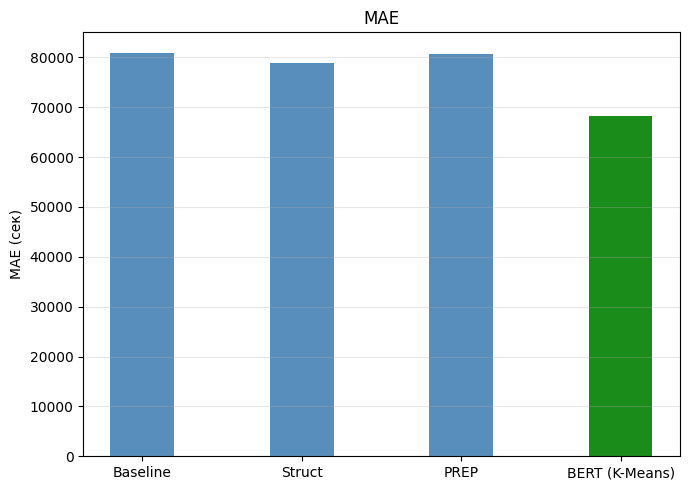

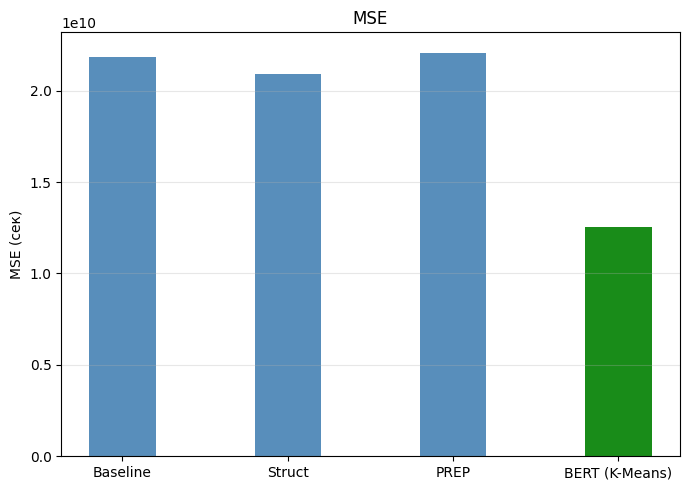

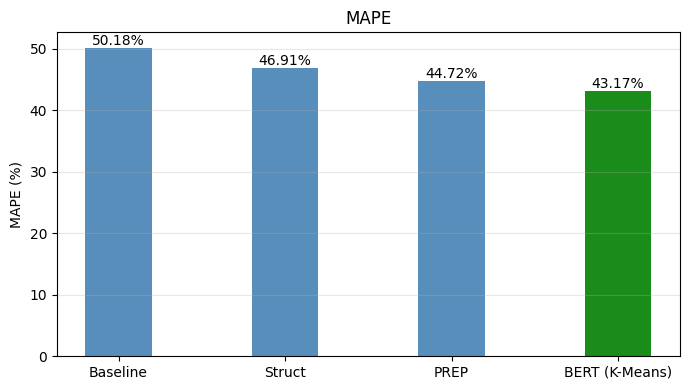

In [10]:
import matplotlib.pyplot as plt
import numpy as np

methods_plot = summary["Модель"].tolist()
mae_plot = summary["MAE"].tolist()
mse_plot = summary["MSE"].tolist()
mape_plot = summary["MAPE"].tolist()

x = np.arange(len(methods_plot))
colors = ["steelblue"] * 3 + ["green"] + ["steelblue"]


# ---------------- MAE ----------------
plt.figure(figsize=(7,5))
bars = plt.bar(x, mae_plot, color=colors, alpha=0.9, width=0.4)
plt.xticks(x, methods_plot)
plt.ylabel("MAE (сек)")
plt.title("MAE")
plt.grid(axis="y", alpha=0.3)



plt.tight_layout()
plt.show()


# ---------------- MSE ----------------
plt.figure(figsize=(7,5))
bars = plt.bar(x, mse_plot, color=colors, alpha=0.9, width=0.4)
plt.xticks(x, methods_plot)
plt.ylabel("MSE (сек)")
plt.title("MSE")
plt.grid(axis="y", alpha=0.3)



plt.tight_layout()
plt.show()


# ---------------- MAPE ----------------
plt.figure(figsize=(7,4))
bars = plt.bar(x, mape_plot, color=colors, alpha=0.9, width=0.4)
plt.xticks(x, methods_plot)
plt.ylabel("MAPE (%)")
plt.title("MAPE")
plt.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, mape_plot):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{val:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()
